In [2]:
from cubes.construct.buildingconfig import load_building_config
from cubes.construct.building import Building
from cubes.package.utilities import get_rdd_file
from cubes.package import weather
from cubes.package.envconfig import EnvConfig
from cubes.package.simple_simulation import prepare_simulation
#from cubes.construct.core import materials_evaluator, windows_evaluator
import os
import pandas as pd
from geomeppy import IDF
import pathlib as Path
import esoreader

materials = pd.read_pickle('/workspaces/CUBES/cubes/materials.pickle')
windows = pd.read_pickle('/workspaces/CUBES/cubes/windows.pickle')

files_dir = os.getcwd()

bc_file_path = "parsons_bc.json"
#bc_file_path = "/workspaces/CUBES/exp/hannes/Leiden-study/01_evaluate_input/evaluation_always_occupied/case_0/year_2022/rep_0/input_c.json"
#bc_file_path = "/workspaces/CUBES/exp/hannes/Leiden-study/01_evaluate_input/evaluation_deterministic_occupancy/case_0/year_2022/rep_0/input_c.json"

BC = load_building_config(bc_file_path, files_dir=files_dir)
EC = EnvConfig(files_dir=files_dir)
#building=Building(BC,materials_evaluator(),windows_evaluator())
building=Building(BC,materials,windows)
building.build()

idf = building.get_idf()
idf = weather.get_weather_file_and_adapt_idf(
        idf=idf, building_config=BC, env_config=EC
    )

idf.idfobjects["RUNPERIOD"][0].Begin_Month = 2
idf.idfobjects["RUNPERIOD"][0].Begin_Day_of_Month = 4
idf.idfobjects["RUNPERIOD"][0].Begin_Year = 2024
idf.idfobjects["RUNPERIOD"][0].End_Month = 2
idf.idfobjects["RUNPERIOD"][0].End_Day_of_Month = 14
idf.idfobjects["RUNPERIOD"][0].End_Year = 2024
idf.idfobjects["RUNPERIOD"][0].Day_of_Week_for_Start_Day = "Sunday"


idf.idfobjects["SIMULATIONCONTROL"][0].Do_Zone_Sizing_Calculation = "Yes"
idf.idfobjects["SIMULATIONCONTROL"][0].Do_System_Sizing_Calculation = "Yes"
idf.idfobjects["SIMULATIONCONTROL"][0].Do_Plant_Sizing_Calculation = "Yes"
idf.idfobjects["SIMULATIONCONTROL"][0].Run_Simulation_for_Sizing_Periods = "No"
idf.idfobjects["SIMULATIONCONTROL"][
    0
].Run_Simulation_for_Weather_File_Run_Periods = "Yes"
idf.idfobjects["SIMULATIONCONTROL"][
    0
].Do_HVAC_Sizing_Simulation_for_Sizing_Periods = "No"

idf.idfobjects["BUILDING"][0].Minimum_Number_of_Warmup_Days = 20

idf.idfobjects["SITE:LOCATION"][0].Name = "BRENTWOOD"

idf.newidfobject("OUTPUT:VARIABLE",
                Key_Value="*",
                Variable_Name= "Zone Mean Air Temperature",
                Reporting_Frequency= "Timestep")

idf.newidfobject("OUTPUT:VARIABLE",
                Key_Value="*",
                Variable_Name= "Boiler NaturalGas Energy",
                Reporting_Frequency= "Timestep")


temp_output_path = files_dir + "/temp"
weather_path = files_dir + "/weather.epw"
rdd_file_path = files_dir + "/building_model.rdd"
idf.save("parsons.idf")


<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


BRENTWOOD


In [44]:
idf.run(
        expandobjects=False,
        readvars=True,
        weather=weather_path,
        output_directory=temp_output_path,
        verbose="q",
    )

In [3]:
eso = esoreader.read_from_path("temp/eplusout.eso")
df_gas = eso.to_frame('Boiler NaturalGas Energy')
df_temp = eso.to_frame('Zone Mean Air Temperature')

<Axes: >

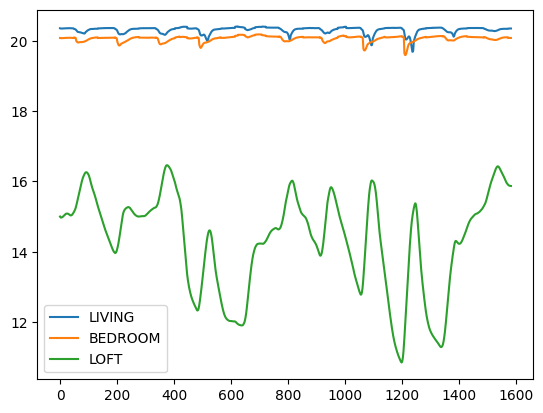

In [4]:
df_temp.plot()

In [5]:
df_gas

,MAIN BOILER,DHW MAIN BOILER
0,1.262736e+06,0.0
1,1.245445e+06,0.0
2,1.230026e+06,0.0
3,1.214653e+06,0.0
4,1.197768e+06,0.0
...,...,...
1579,9.978645e+05,0.0
1580,9.989538e+05,0.0
1581,1.001223e+06,0.0
1582,1.004111e+06,0.0


In [51]:
print("kWh of natural gas: ", (df_gas["MAIN BOILER"].sum()/1000000)*0.2777777778)

kWh of natural gas:  575.196875193331


<Axes: >

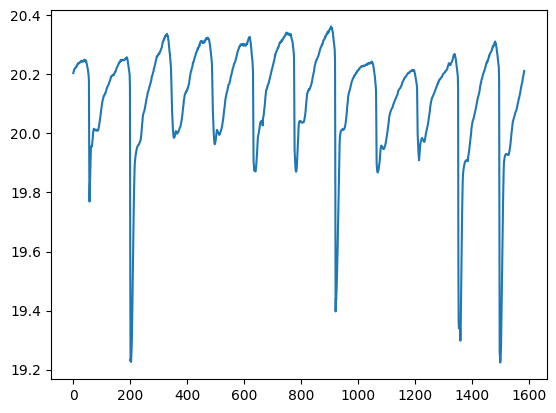

In [15]:
df.BEDROOM.plot()

In [5]:
materials_evaluator()
windows_evaluator()

2024-02-19 13:42:13.910 | INFO     | cubes.data_processing.evaluators:__call__:55 - Processing materials data.
2024-02-19 13:42:14.099 | INFO     | cubes.data_processing.evaluators:__call__:72 - Processing windows data.


{'CLEAR 3MM': WindowMaterialGlazing(name='CLEAR 3MM', optical_data_type='SpectralAverage', data_set_name=nan, thickness=0.003, solar_transmittance=0.837, front_side_solar_reflectance=0.075, back_side_solar_reflectance=0.075, visible_transmittance=0.898, front_side_visible_reflectance=0.081, back_side_visible_reflectance=0.081, infrared_transmittance=0.0, front_side_infrared_emissivity=0.84, back_side_infrared_emissivity=0.84, conductivity=0.9),
 'LoE SPEC SEL CLEAR 3MM': WindowMaterialGlazing(name='LoE SPEC SEL CLEAR 3MM', optical_data_type='SpectralAverage', data_set_name=nan, thickness=0.003, solar_transmittance=0.45, front_side_solar_reflectance=0.34, back_side_solar_reflectance=0.37, visible_transmittance=0.78, front_side_visible_reflectance=0.07, back_side_visible_reflectance=0.06, infrared_transmittance=0.0, front_side_infrared_emissivity=0.84, back_side_infrared_emissivity=0.03, conductivity=0.9),
 'Clear_6mm_CODE': WindowMaterialGlazing(name='Clear_6mm_CODE', optical_data_type=

In [6]:
materials = pd.read_pickle('/workspaces/CUBES/cubes/materials.pickle')
windows = pd.read_pickle('/workspaces/CUBES/cubes/windows.pickle')

In [7]:
materials

{'Clay tile - hollow - 2 cells deep - 200mm': NoMassMaterial(name='Clay tile - hollow - 2 cells deep - 200mm', roughness='MediumSmooth', resistance=0.33, thermal_absorptance=0.9, solar_absorptance=0.7, visual_absorptance=0.7),
 'Asphalt roll roofing': NoMassMaterial(name='Asphalt roll roofing', roughness='VeryRough', resistance=0.026, thermal_absorptance=0.9, solar_absorptance=0.7, visual_absorptance=0.7),
 'F05 Ceiling air space resistance': Material(name='F05 Ceiling air space resistance', rho=nan, cp=nan, k=nan, roughness=nan, thermal_absorptance=nan, solar_absorptance=nan, visual_absorptance=nan),
 'F04 Wall air space resistance': Material(name='F04 Wall air space resistance', rho=nan, cp=nan, k=nan, roughness=nan, thermal_absorptance=nan, solar_absorptance=nan, visual_absorptance=nan),
 'AIR-GAP': NoMassMaterial(name='AIR-GAP', roughness='Smooth', resistance=0.15, thermal_absorptance=0.9, solar_absorptance=0.7, visual_absorptance=0.7),
 'UPPER-FLOOR': NoMassMaterial(name='UPPER-FL